# Final EDA

/content
Cloning into 'Gemstone-Price-Prediction'...
remote: Enumerating objects: 91, done.
remote: Counting objects: 100% (91/91), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 91 (delta 34), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (91/91), 5.65 MiB | 5.54 MiB/s, done.
Resolving deltas: 100% (34/34), done.
/content/Gemstone-Price-Prediction


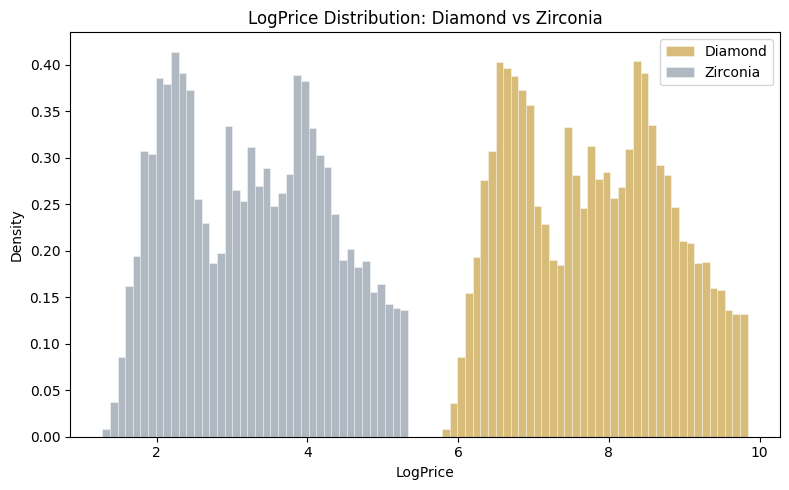

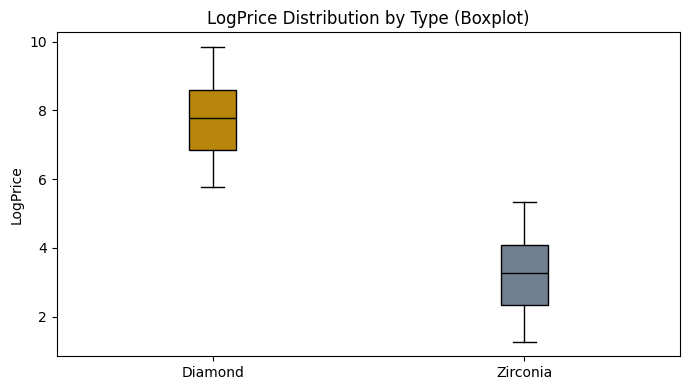

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

%cd /content
!rm -rf Gemstone-Price-Prediction
!git clone https://github.com/Wathsala2002/Gemstone-Price-Prediction.git
%cd Gemstone-Price-Prediction

PATH = "data/Train Dataset with Log Price.csv"

df = pd.read_csv(PATH)
df.columns = [c.strip() for c in df.columns]

# Make sure required columns exist
assert "LogPrice" in df.columns, "LogPrice column not found."
assert "Type" in df.columns, "Type column not found." # Changed 'type' to 'Type'

# Clean type labels
df["type_lc"] = df["Type"].astype(str).str.strip().str.lower() # Changed 'type' to 'Type'

# Keep only the two types of interest (in case of typos/others)
plot_df = df[df["type_lc"].isin(["diamond", "zirconia"])].copy()

# Drop missing LogPrice
plot_df["LogPrice"] = pd.to_numeric(plot_df["LogPrice"], errors="coerce")
plot_df = plot_df.dropna(subset=["LogPrice"])

# Colors (main + pleasant companion)
colors = {
    "diamond": "darkgoldenrod",
    "zirconia": "slategray"   # eye-pleasant contrast
}

# --- Chart: Overlaid histograms (density) ---
plt.figure(figsize=(8, 5))
bins = 40

for t in ["diamond", "zirconia"]:
    data = plot_df.loc[plot_df["type_lc"] == t, "LogPrice"]
    if len(data) > 0:
        plt.hist(
            data,
            bins=bins,
            density=True,
            alpha=0.55,
            label=t.capitalize(),
            color=colors[t],
            edgecolor="white",
            linewidth=0.5
        )

plt.title("LogPrice Distribution: Diamond vs Zirconia")
plt.xlabel("LogPrice")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

# --- Optional: Side-by-side boxplot (nice for report) ---
plt.figure(figsize=(7, 4))
data_d = plot_df.loc[plot_df["type_lc"] == "diamond", "LogPrice"]
data_z = plot_df.loc[plot_df["type_lc"] == "zirconia", "LogPrice"]

bp = plt.boxplot([data_d, data_z], tick_labels=["Diamond", "Zirconia"], patch_artist=True) # Changed labels to tick_labels

bp["boxes"][0].set_facecolor(colors["diamond"])
bp["boxes"][1].set_facecolor(colors["zirconia"])
for med in bp["medians"]:
    med.set_color("black")

plt.title("LogPrice Distribution by Type (Boxplot)")
plt.ylabel("LogPrice")
plt.tight_layout()
plt.show()

/tmp/ipykernel_477/1353524935.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


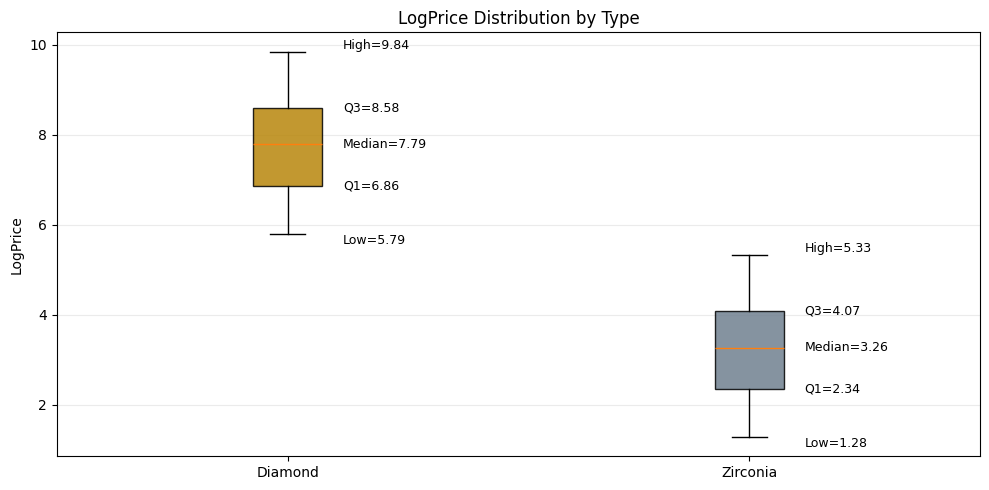

In [47]:
# Exact columns in your dataset
df["LogPrice"] = pd.to_numeric(df["LogPrice"], errors="coerce")
df["Type_lc"] = df["Type"].astype(str).str.strip().str.lower()

# Keep only the two types and non-missing logprice
df = df[df["Type_lc"].isin(["diamond", "zirconia"])].dropna(subset=["LogPrice"]).copy()

groups = ["diamond", "zirconia"]
labels = ["Diamond", "Zirconia"]
data = [df.loc[df["Type_lc"] == g, "LogPrice"].values for g in groups]

# Helper: compute boxplot stats manually
def box_stats(arr):
    arr = np.asarray(arr)
    q1 = np.percentile(arr, 25)
    med = np.percentile(arr, 50)
    q3 = np.percentile(arr, 75)
    iqr = q3 - q1
    low_bound = q1 - 1.5 * iqr
    high_bound = q3 + 1.5 * iqr
    whisk_low = arr[arr >= low_bound].min()
    whisk_high = arr[arr <= high_bound].max()
    return q1, med, q3, whisk_low, whisk_high

stats_list = [box_stats(d) for d in data]

# ---- Plot ----
plt.figure(figsize=(10, 5))

bp = plt.boxplot(
    data,
    labels=labels,
    patch_artist=True,
    showfliers=True
)

# Colors (main = darkgoldenrod)
colors = ["darkgoldenrod", "slategray"]
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.85)

plt.title("LogPrice Distribution by Type")
plt.ylabel("LogPrice")
plt.grid(axis="y", alpha=0.25)

# Annotate values on plot
for i, (q1, med, q3, wl, wh) in enumerate(stats_list, start=1):
    # Slight horizontal offset so text doesn't overlap the box line
    x = i + 0.12

    plt.text(x, med, f"Median={med:.2f}", va="center", fontsize=9)
    plt.text(x, q1,  f"Q1={q1:.2f}", va="center", fontsize=9)
    plt.text(x, q3,  f"Q3={q3:.2f}", va="center", fontsize=9)
    plt.text(x, wl,  f"Low={wl:.2f}", va="top", fontsize=9)
    plt.text(x, wh,  f"High={wh:.2f}", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

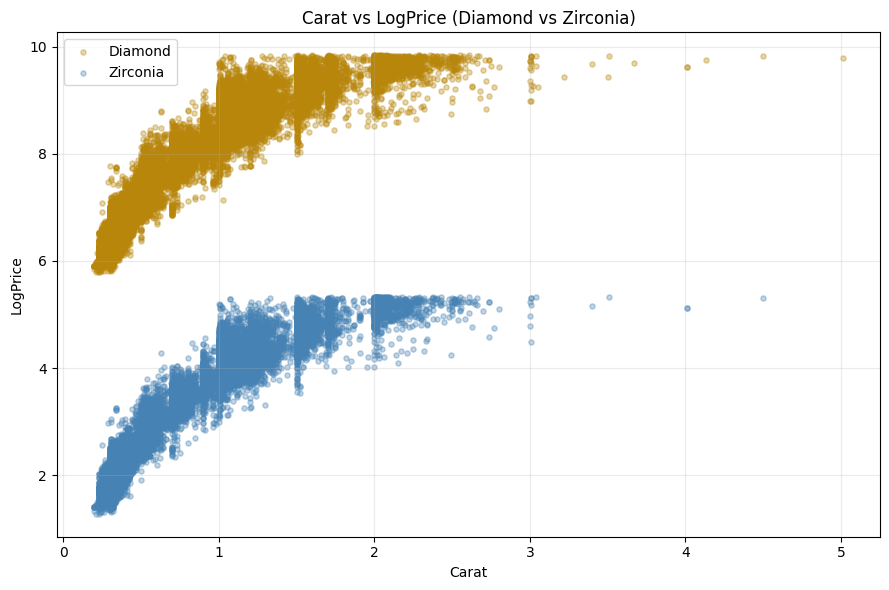

In [48]:
# Use exact column names from your dataset
# Type, Carat, LogPrice
df["Carat"] = pd.to_numeric(df["Carat"], errors="coerce")
df["LogPrice"] = pd.to_numeric(df["LogPrice"], errors="coerce")
df["Type_lc"] = df["Type"].astype(str).str.strip().str.lower()

# Keep valid rows
df = df.dropna(subset=["Carat", "LogPrice"]).copy()
df = df[df["Carat"] > 0].copy()

# Split by type
diamonds = df[df["Type_lc"] == "diamond"]
zirconia = df[df["Type_lc"] == "zirconia"]

# Plot: Carat vs LogPrice (Diamond main; Zirconia optional)
plt.figure(figsize=(9, 6))

plt.scatter(diamonds["Carat"], diamonds["LogPrice"],
            s=14, alpha=0.35, color="darkgoldenrod", label="Diamond")

if len(zirconia) > 0:
    plt.scatter(zirconia["Carat"], zirconia["LogPrice"],
                s=14, alpha=0.35, color="steelblue", label="Zirconia")

plt.title("Carat vs LogPrice (Diamond vs Zirconia)")
plt.xlabel("Carat")
plt.ylabel("LogPrice")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
import numpy as np
import statsmodels.formula.api as smf

alpha = 0.05

d = df[["Type","Carat","LogPrice"]].copy()
d["Carat"] = pd.to_numeric(d["Carat"], errors="coerce")
d["LogPrice"] = pd.to_numeric(d["LogPrice"], errors="coerce")
d["Type"] = d["Type"].astype(str).str.strip().str.lower()
d = d.dropna()
d = d[(d["Carat"] > 0) & (d["Type"].isin(["diamond","zirconia"]))].copy()

# Center carat so the Type difference is interpreted at the average carat
d["Carat_c"] = d["Carat"] - d["Carat"].mean()

m = smf.ols("LogPrice ~ Carat_c + C(Type)", data=d).fit(cov_type="HC3")

p_type = m.pvalues["C(Type)[T.zirconia]"]
coef = m.params["C(Type)[T.zirconia]"]

print("TEST: Type effect on LogPrice controlling for Carat")
print("H0: No difference in expected LogPrice between types at same Carat (beta_Type=0)")
print("H1: Difference exists (beta_Type!=0)")
print("coef (zirconia - diamond) =", coef)
print("p-value =", p_type)
print("Decision:", "REJECT H0" if p_type < alpha else "FAIL TO REJECT H0")

# Optional: convert log difference to multiplicative ratio (if LogPrice is natural log)
print("Approx price ratio zirconia/diamond =", np.exp(coef))

TEST: Type effect on LogPrice controlling for Carat
H0: No difference in expected LogPrice between types at same Carat (beta_Type=0)
H1: Difference exists (beta_Type!=0)
coef (zirconia - diamond) = -4.514730470183454
p-value = 0.0
Decision: REJECT H0
Approx price ratio zirconia/diamond = 0.01094655515225582


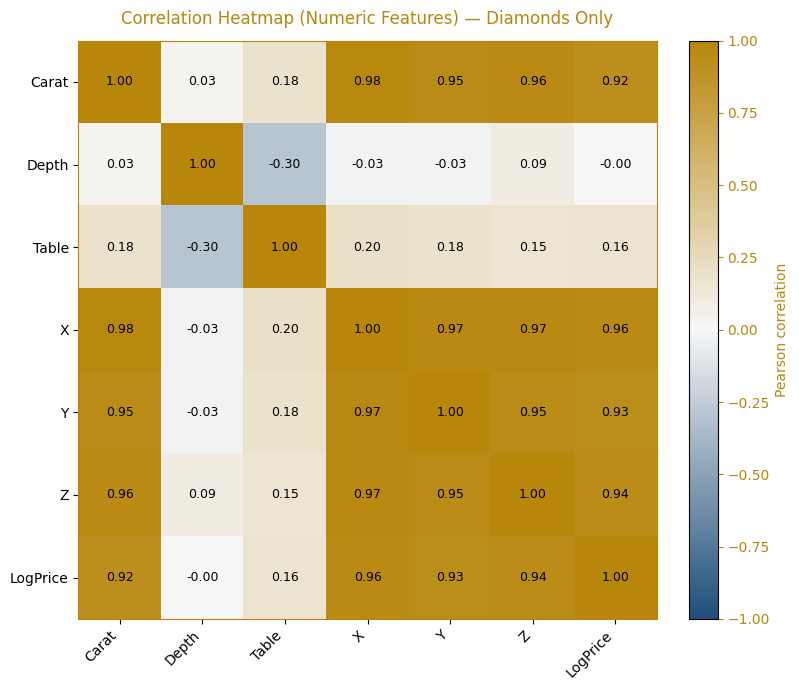

In [50]:
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# Filter to Diamonds only
# ----------------------------
df["Type_lc"] = df["Type"].astype(str).str.strip().str.lower()
df_d = df[df["Type_lc"] == "diamond"].copy()

# ----------------------------
# Numeric correlation (diamond only)
# ----------------------------
numeric_cols = ["Carat", "Depth", "Table", "X", "Y", "Z", "LogPrice"]  # removed "Price"
for c in numeric_cols:
    df_d[c] = pd.to_numeric(df_d[c], errors="coerce")

corr = df_d[numeric_cols].corr(method="pearson")

# ----------------------------
# Plot correlation heatmap (matplotlib only)
# ----------------------------
accent = "darkgoldenrod"
cmap = LinearSegmentedColormap.from_list(
    "gold_diverging",
    ["#1f4e79", "#f7f7f7", "#b8860b"],
    N=256
)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(numeric_cols)))
ax.set_yticks(np.arange(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
ax.set_yticklabels(numeric_cols)

ax.set_title("Correlation Heatmap (Numeric Features) — Diamonds Only", color=accent, pad=12)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        val = corr.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pearson correlation", color=accent)
cbar.ax.yaxis.set_tick_params(color=accent)
plt.setp(cbar.ax.get_yticklabels(), color=accent)

for spine in ax.spines.values():
    spine.set_color(accent)

plt.tight_layout()
plt.show()

/content
Cloning into 'Gemstone-Price-Prediction'...
remote: Enumerating objects: 91, done.
remote: Counting objects: 100% (91/91), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 91 (delta 34), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (91/91), 5.65 MiB | 5.49 MiB/s, done.
Resolving deltas: 100% (34/34), done.
/content/Gemstone-Price-Prediction

Boxplot values by Cut (Diamonds):
               n  min_val     q1  median     q3  max_val   mean    std
Cut                                                                   
Fair        1282    5.820  7.611   8.101  8.550    9.830  8.091  0.767
Good        3915    5.790  7.034   7.980  8.503    9.836  7.825  0.976
Very Good   9646    5.817  6.820   7.892  8.590    9.842  7.801  1.037
Premium    10989    5.787  6.959   8.091  8.754    9.843  7.958  1.028
Ideal      17218    5.787  6.778   7.504  8.463    9.842  7.643  0.994


/tmp/ipykernel_477/792684093.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


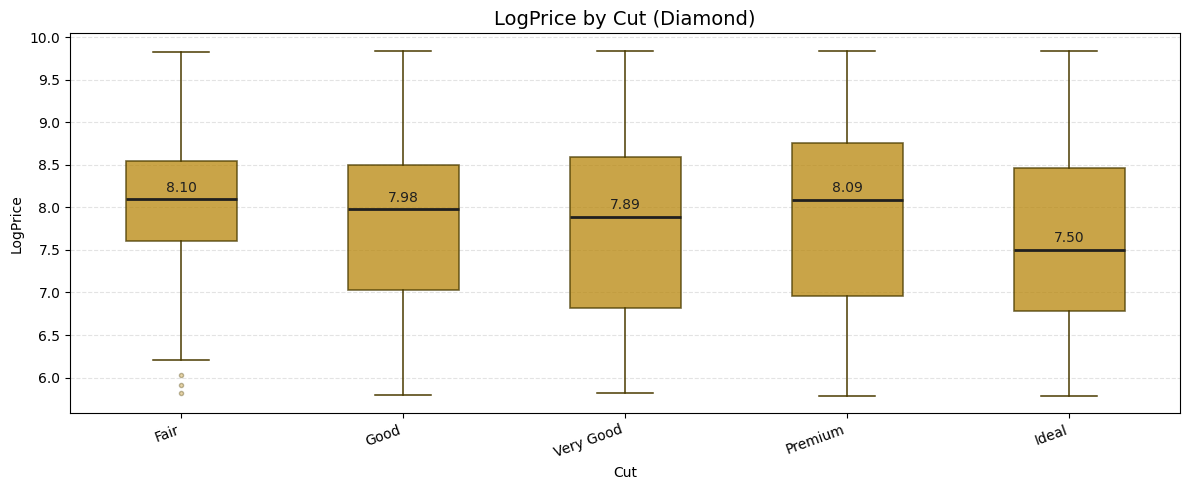

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%cd /content
!rm -rf Gemstone-Price-Prediction
!git clone https://github.com/Wathsala2002/Gemstone-Price-Prediction.git
%cd Gemstone-Price-Prediction

PATH = "data/Train Dataset with Log Price.csv"

# Load
df = pd.read_csv(PATH)

# Filter only Diamonds
df = df[df["Type"].astype(str).str.strip().str.lower() == "diamond"].copy()

# Drop missing essentials
df = df.dropna(subset=["Cut", "LogPrice"])

# Cut order (use your preferred order; keeps only those present)
cut_order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
order = [c for c in cut_order if c in set(df["Cut"].unique())]
if not order:
    order = sorted(df["Cut"].unique())

# ---- 1) Compute boxplot stats (values) ----
summary = (
    df.groupby("Cut")["LogPrice"]
      .agg(
          n="count",
          min_val="min",
          q1=lambda s: s.quantile(0.25),
          median="median",
          q3=lambda s: s.quantile(0.75),
          max_val="max",
          mean="mean",
          std="std"
      )
      .loc[order]
)

print("\nBoxplot values by Cut (Diamonds):")
print(summary.round(3))

# ---- 2) Plot boxplot ----
data = [df.loc[df["Cut"] == c, "LogPrice"].values for c in order]

fig, ax = plt.subplots(figsize=(12, 5))

bp = ax.boxplot(
    data,
    labels=order,
    patch_artist=True,
    showfliers=True
)

# Styling (main color requested)
main_color = "darkgoldenrod"
secondary_edge = "#4a3b00"
median_color = "#1f1f1f"

for box in bp["boxes"]:
    box.set(facecolor=main_color, edgecolor=secondary_edge, alpha=0.75, linewidth=1.2)

for whisker in bp["whiskers"]:
    whisker.set(color=secondary_edge, linewidth=1.1)

for cap in bp["caps"]:
    cap.set(color=secondary_edge, linewidth=1.1)

for median in bp["medians"]:
    median.set(color=median_color, linewidth=2)

for flier in bp["fliers"]:
    flier.set(marker="o", markersize=3, markerfacecolor=main_color, markeredgecolor=secondary_edge, alpha=0.35)

ax.set_title("LogPrice by Cut (Diamond)", fontsize=14)
ax.set_xlabel("Cut")
ax.set_ylabel("LogPrice")
ax.grid(axis="y", linestyle="--", alpha=0.35)

plt.xticks(rotation=20, ha="right")

# ---- 3) Annotate medians (values on the chart) ----
medians = summary["median"].values
for i, m in enumerate(medians, start=1):
    ax.text(i, m + 0.05, f"{m:.2f}", ha="center", va="bottom", fontsize=10, color="#1f1f1f")

plt.tight_layout()
plt.show()

/content
Cloning into 'Gemstone-Price-Prediction'...
remote: Enumerating objects: 91, done.
remote: Counting objects: 100% (91/91), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 91 (delta 34), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (91/91), 5.65 MiB | 5.47 MiB/s, done.
Resolving deltas: 100% (34/34), done.
/content/Gemstone-Price-Prediction


/tmp/ipykernel_477/41883850.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data, labels=order, patch_artist=True, showfliers=True)


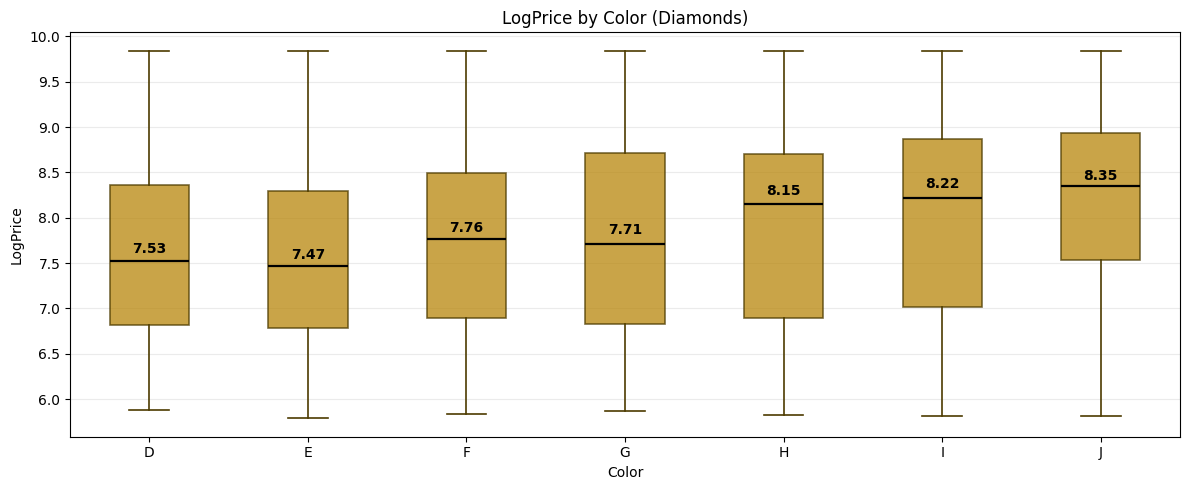

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%cd /content
!rm -rf Gemstone-Price-Prediction
!git clone https://github.com/Wathsala2002/Gemstone-Price-Prediction.git
%cd Gemstone-Price-Prediction

PATH = "data/Train Dataset with Log Price.csv"
df = pd.read_csv(PATH)

# Filter diamonds
df["Type"] = df["Type"].astype(str).str.strip().str.lower()
diam = df[df["Type"] == "diamond"].copy()

# Clean
diam["LogPrice"] = pd.to_numeric(diam["LogPrice"], errors="coerce")
diam["Color"] = diam["Color"].astype(str).str.strip()
diam = diam.dropna(subset=["LogPrice", "Color"])

# Color order (typical diamond grades)
color_order = ["D", "E", "F", "G", "H", "I", "J"]
order = [c for c in color_order if c in set(diam["Color"].unique())]
if not order:
    order = sorted(diam["Color"].unique())

# Prepare data
data = [diam.loc[diam["Color"] == c, "LogPrice"].values for c in order]

# Compute quartiles + medians (for placing label inside box)
q1 = [np.percentile(vals, 25) for vals in data]
q3 = [np.percentile(vals, 75) for vals in data]
medians = [np.median(vals) for vals in data]
iqr = [q3[i] - q1[i] for i in range(len(order))]

# Plot
plt.figure(figsize=(12, 5))
bp = plt.boxplot(data, labels=order, patch_artist=True, showfliers=True)

# Styling (main color darkgoldenrod)
main = "darkgoldenrod"
edge = "#4d3b00"

for box in bp["boxes"]:
    box.set(facecolor=main, edgecolor=edge, alpha=0.75, linewidth=1.2)
for whisker in bp["whiskers"]:
    whisker.set(color=edge, linewidth=1.2)
for cap in bp["caps"]:
    cap.set(color=edge, linewidth=1.2)
for med in bp["medians"]:
    med.set(color="black", linewidth=1.6)

plt.title("LogPrice by Color (Diamonds)")
plt.xlabel("Color")
plt.ylabel("LogPrice")
plt.grid(axis="y", alpha=0.25)

# Annotate median slightly above median line, but INSIDE the box
for i, med in enumerate(medians, start=1):
    # move label up by 8% of IQR (if IQR is 0, use a tiny fallback)
    offset = 0.08 * (iqr[i-1] if iqr[i-1] > 0 else 0.05)
    y = min(med + offset, q3[i-1] - 0.02 * (iqr[i-1] if iqr[i-1] > 0 else 0.05))

    plt.text(
        i, y, f"{med:.2f}",
        ha="center", va="center",
        fontsize=10, fontweight="bold", color="black"
    )

plt.tight_layout()
plt.show()

/content
Cloning into 'Gemstone-Price-Prediction'...
remote: Enumerating objects: 91, done.
remote: Counting objects: 100% (91/91), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 91 (delta 34), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (91/91), 5.65 MiB | 5.49 MiB/s, done.
Resolving deltas: 100% (34/34), done.
/content/Gemstone-Price-Prediction

Boxplot values (Diamonds):
Clarity     n    q1  median    q3   iqr  whisker_low  whisker_high  outliers_count
     I1   586 7.636   8.122 8.568 0.932        6.273         9.827              14
     IF  1383 6.797   6.989 7.797 1.000        6.107         9.287             110
    SI1 10511 6.991   7.938 8.564 1.573        5.787         9.842               0
    SI2  7344 7.727   8.312 8.666 0.939        6.323         9.842             316
    VS1  6471 6.771   7.609 8.724 1.954        5.790         9.841               0
    VS2  9782 6.802   7.633 8.707 1.905        5.811         9.843              

/tmp/ipykernel_477/2781028298.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = diam.groupby("Clarity")["LogPrice"]
/tmp/ipykernel_477/2781028298.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data, labels=labels, patch_artist=True, showfliers=True)


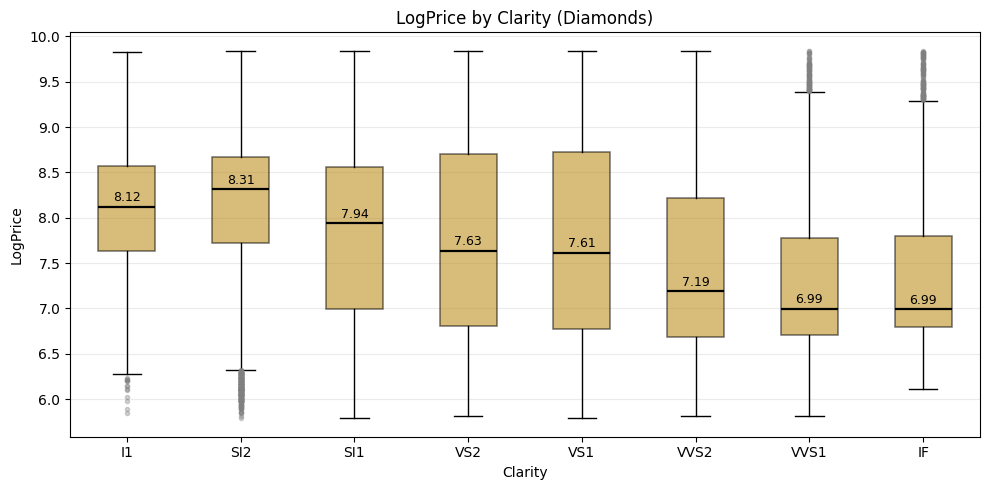

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%cd /content
!rm -rf Gemstone-Price-Prediction
!git clone https://github.com/Wathsala2002/Gemstone-Price-Prediction.git
%cd Gemstone-Price-Prediction

PATH = "data/Train Dataset with Log Price.csv"

# --- Filter diamonds only ---
df["Type"] = df["Type"].astype(str).str.strip().str.lower()
diam = df[df["Type"] == "diamond"].copy()

# --- Clean / ensure numeric ---
diam["LogPrice"] = pd.to_numeric(diam["LogPrice"], errors="coerce")
diam["Clarity"] = diam["Clarity"].astype(str).str.strip()
diam = diam.dropna(subset=["Clarity", "LogPrice"])

# --- Clarity order (common diamond grades) ---
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]
present = [c for c in clarity_order if c in set(diam["Clarity"].unique())]
if present:
    diam["Clarity"] = pd.Categorical(diam["Clarity"], categories=present, ordered=True)

# --- Prepare grouped data ---
groups = diam.groupby("Clarity")["LogPrice"]
labels = [str(k) for k in groups.groups.keys()]
data = [groups.get_group(k).values for k in groups.groups.keys()]

# --- Compute boxplot stats (values you want) ---
def box_stats(arr):
    arr = np.asarray(arr)
    arr = arr[~np.isnan(arr)]
    q1 = np.percentile(arr, 25)
    med = np.percentile(arr, 50)
    q3 = np.percentile(arr, 75)
    iqr = q3 - q1
    low_fence = q1 - 1.5 * iqr
    high_fence = q3 + 1.5 * iqr
    whisk_low = arr[arr >= low_fence].min()
    whisk_high = arr[arr <= high_fence].max()
    outliers = arr[(arr < whisk_low) | (arr > whisk_high)]
    return {
        "n": len(arr),
        "q1": q1,
        "median": med,
        "q3": q3,
        "iqr": iqr,
        "whisker_low": whisk_low,
        "whisker_high": whisk_high,
        "outliers_count": len(outliers),
    }

rows = []
for lab, arr in zip(labels, data):
    s = box_stats(arr)
    s["Clarity"] = lab
    rows.append(s)

stats_df = pd.DataFrame(rows)[
    ["Clarity", "n", "q1", "median", "q3", "iqr", "whisker_low", "whisker_high", "outliers_count"]
].sort_values("Clarity")

print("\nBoxplot values (Diamonds):")
print(stats_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# --- Plot (same style) + annotate medians ---
plt.figure(figsize=(10, 5))
bp = plt.boxplot(data, labels=labels, patch_artist=True, showfliers=True)

# Style: main color darkgoldenrod + pleasant neutrals
for box in bp["boxes"]:
    box.set(facecolor="darkgoldenrod", alpha=0.55, edgecolor="black", linewidth=1.1)
for median in bp["medians"]:
    median.set(color="black", linewidth=1.6)
for whisker in bp["whiskers"]:
    whisker.set(color="black", linewidth=1.0)
for cap in bp["caps"]:
    cap.set(color="black", linewidth=1.0)
for flier in bp["fliers"]:
    flier.set(marker="o", markerfacecolor="gray", markeredgecolor="gray", alpha=0.35, markersize=3)

# Annotate medians on the chart
medians = stats_df.set_index("Clarity")["median"].to_dict()
for i, lab in enumerate(labels, start=1):
    m = medians.get(lab, np.nan)
    if not np.isnan(m):
        plt.text(i, m + 0.03, f"{m:.2f}", ha="center", va="bottom", fontsize=9)

plt.title("LogPrice by Clarity (Diamonds)")
plt.xlabel("Clarity")
plt.ylabel("LogPrice")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

In [54]:
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Optional Dunn post-hoc for Kruskal-Wallis:
# !pip -q install scikit-posthocs
try:
    import scikit_posthocs as sp
    HAVE_SPH = True
except Exception:
    HAVE_SPH = False

# -----------------------------
# CONFIG
# -----------------------------
ALPHA = 0.05

# If LogPrice is log10(price) (instead of ln), set LOG_BASE_10=True (only matters if you convert back to price)
LOG_BASE_10 = False


# -----------------------------
# HELPERS: effect sizes
# -----------------------------
def cliffs_delta_from_u(u_stat, n1, n2):
    """Cliff's delta from Mann–Whitney U (two-sided). Range [-1, 1]."""
    return (2 * u_stat) / (n1 * n2) - 1

def eta_squared_from_anova_groups(y, groups):
    """
    Eta squared (η²) for one-way ANOVA:
    η² = SS_between / SS_total
    groups: array-like categories same length as y
    """
    y = np.asarray(y)
    groups = np.asarray(groups)
    overall_mean = np.mean(y)
    ss_total = np.sum((y - overall_mean)**2)

    ss_between = 0.0
    for g in np.unique(groups):
        yg = y[groups == g]
        ss_between += len(yg) * (np.mean(yg) - overall_mean)**2

    return ss_between / ss_total if ss_total > 0 else np.nan

def epsilon_squared_kruskal(H, n, k):
    """
    Epsilon squared (ε²) for Kruskal–Wallis:
    ε² = (H - k + 1) / (n - k)
    """
    denom = (n - k)
    if denom <= 0:
        return np.nan
    return (H - k + 1) / denom

def pretty_decision(p, alpha=0.05):
    return "Reject H0" if p < alpha else "Fail to reject H0"

# -----------------------------
# Reload and prepare data
# -----------------------------
%cd /content
!rm -rf Gemstone-Price-Prediction
!git clone https://github.com/Wathsala2002/Gemstone-Price-Prediction.git
%cd Gemstone-Price-Prediction

PATH = "data/Train Dataset with Log Price.csv"
df = pd.read_csv(PATH)
df.columns = [c.strip().lower() for c in df.columns] # Convert all column names to lowercase

assert "logprice" in df.columns, "logprice column not found (check spelling/case)."
assert "type" in df.columns, "type column not found (needed for Diamond vs Zirconia test)."

# normalize type labels
df["type_lc"] = df["type"].astype(str).str.strip().str.lower()

# coerce numeric
for c in ["carat", "depth", "table", "x", "y", "z", "price", "logprice"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Basic EDA subset (remove missing essentials)
need = ["logprice", "carat", "depth", "table", "x", "y", "z", "cut", "color", "clarity", "type_lc"]
df = df.dropna(subset=[c for c in need if c in df.columns]).copy()

# Sanity: remove non-positive geometry
for c in ["carat", "x", "y", "z"]:
    df = df[df[c] > 0].copy()

# Derived fields
df["log_carat"] = np.log(df["carat"].clip(lower=1e-9))


# =========================================================
# TEST 1) Diamond vs Zirconia difference in LogPrice
# Mann–Whitney U + Cliff’s delta
# =========================================================
print("\n" + "="*90)
print("TEST 1: Diamond vs Zirconia difference in LogPrice")
print("H0: Diamond and Zirconia LogPrice distributions are the same")
print("H1: Distributions differ")
print(f"alpha = {ALPHA}")

diamond_lp = df.loc[df["type_lc"] == "diamond", "logprice"].dropna()
zirconia_lp = df.loc[df["type_lc"] == "zirconia", "logprice"].dropna()

if len(diamond_lp) == 0 or len(zirconia_lp) == 0:
    print("ERROR: Missing diamond or zirconia rows after cleaning.")
else:
    mw = stats.mannwhitneyu(diamond_lp, zirconia_lp, alternative="two-sided")
    delta = cliffs_delta_from_u(mw.statistic, len(diamond_lp), len(zirconia_lp))

    print(f"Mann–Whitney U statistic = {mw.statistic:.4g}, p-value = {mw.pvalue:.4g}")
    print(f"Cliff's delta = {delta:.4g}  (near \u00b11 = huge effect)")

    print("Decision:", pretty_decision(mw.pvalue, ALPHA))
    if mw.pvalue < ALPHA:
        print("Conclusion: Type has a statistically significant effect on LogPrice.")
        print("Implication: strongly supports separate modeling or using Type as a major feature.")
    else:
        print("Conclusion: No significant evidence that Type affects LogPrice (unexpected for this domain).")


# =========================================================
# TEST 2) Cut/Color/Clarity effect beyond carat (Diamonds)
# Steps:
#   A) Create AdjustedLogPrice = residual from LogPrice ~ log(carat)
#   B) For each categorical variable:
#       - Levene test (variance equality)
#       - Choose ANOVA if variances ok, else Kruskal–Wallis
#       - Effect size: \u03b7\u00b2 (ANOVA) / \u03b5\u00b2 (Kruskal)
#       - Post-hoc: Tukey (ANOVA) / Dunn-Holm (Kruskal, optional)
# =========================================================
print("\n" + "="*90)
print("TEST 2: Cut/Color/Clarity effect on price BEYOND carat (Diamonds only)")
print("We first remove carat effect using: AdjustedLogPrice = residual(LogPrice ~ log(carat))")
print("Then we test whether AdjustedLogPrice differs across grade categories.")
print(f"alpha = {ALPHA}")

df_d = df[df["type_lc"] == "diamond"].copy()
if len(df_d) == 0:
    print("ERROR: No diamond rows found.")
else:
    # A) baseline adjustment
    base = smf.ols("logprice ~ log_carat", data=df_d).fit()
    df_d["AdjustedLogPrice"] = base.resid

    print(f"\nBaseline fit (Diamonds): LogPrice ~ log(carat)")
    print(f"R-squared (baseline) = {base.rsquared:.4f}  (how much carat alone explains in log-space)")

    def run_group_test(data, group_col):
        tmp = data[[group_col, "AdjustedLogPrice"]].dropna().copy()
        if tmp[group_col].nunique() < 2:
            print(f"\n{group_col}: Not enough groups to test.")
            return None

        # groups arrays
        group_arrays = [g["AdjustedLogPrice"].values for _, g in tmp.groupby(group_col)]
        k = tmp[group_col].nunique()
        n = len(tmp)

        print("\n" + "-"*90)
        print(f"Variable: {group_col}")
        print("H0: All groups have same central tendency of AdjustedLogPrice (mean for ANOVA / distribution for Kruskal)")
        print("H1: At least one group differs")

        # Levene (variance equality guide)
        lev_stat, lev_p = stats.levene(*group_arrays, center="median")
        print(f"Levene test (equal variances guide): p = {lev_p:.4g}")

        # Normality guide (Shapiro on a sample; large n often rejects, so just a guide)
        sample = tmp["AdjustedLogPrice"].sample(n=min(n, 5000), random_state=0)
        sh_stat, sh_p = stats.shapiro(sample)
        print(f"Shapiro test on sample (normality guide only): p = {sh_p:.4g}")

        # Decision: if variances ok -> ANOVA; else -> Kruskal (robust)
        if lev_p >= ALPHA:
            # ANOVA
            f_stat, p = stats.f_oneway(*group_arrays)
            eta2 = eta_squared_from_anova_groups(tmp["AdjustedLogPrice"].values, tmp[group_col].values)

            print(f"\nTEST USED: One-way ANOVA")
            print(f"F = {f_stat:.4g}, p = {p:.4g}")
            print(f"Effect size \u03b7\u00b2 = {eta2:.4g}  (share of variance explained by {group_col})")
            print("Decision:", pretty_decision(p, ALPHA))

            if p < ALPHA:
                print(f"Conclusion: {group_col} significantly affects price beyond carat (Diamonds).")
                print("Post-hoc (Tukey HSD): which pairs differ")
                tuk = pairwise_tukeyhsd(endog=tmp["AdjustedLogPrice"], groups=tmp[group_col], alpha=ALPHA)
                print(tuk)
            else:
                print(f"Conclusion: No significant evidence that {group_col} affects price beyond carat.")

            return {"variable": group_col, "test": "ANOVA", "p": p, "effect": eta2}

        else:
            # Kruskal–Wallis
            H_stat, p = stats.kruskal(*group_arrays)
            eps2 = epsilon_squared_kruskal(H_stat, n, k)

            print(f"\nTEST USED: Kruskal–Wallis (nonparametric)")
            print(f"H = {H_stat:.4g}, p = {p:.4g}")
            print(f"Effect size \u03b5\u00b2 = {eps2:.4g}  (rank-based effect size)")
            print("Decision:", pretty_decision(p, ALPHA))

            if p < ALPHA:
                print(f"Conclusion: {group_col} differs across groups beyond carat (Diamonds).")
                if HAVE_SPH:
                    print("Post-hoc (Dunn test, Holm corrected):")
                    dunn = sp.posthoc_dunn(tmp, val_col="AdjustedLogPrice", group_col=group_col, p_adjust="holm")
                    print(dunn)
                else:
                    print("Post-hoc Dunn not available. Install scikit-posthocs:")
                    print("  !pip install scikit-posthocs")
            else:
                print(f"Conclusion: No significant evidence that {group_col} differs beyond carat.")

            return {"variable": group_col, "test": "Kruskal", "p": p, "effect": eps2}

    results_test2 = []
    for col in ["cut", "color", "clarity"]:
        if col in df_d.columns:
            out = run_group_test(df_d, col)
            if out is not None:
                results_test2.append(out)


# =========================================================
# TEST 3) Depth/Table association (Spearman) with AdjustedLogPrice (Diamonds)
# =========================================================
print("\n" + "="*90)
print("TEST 3: Depth/Table association with AdjustedLogPrice (Diamonds only)")
print("Spearman correlation is used (robust for monotonic / non-linear relationships).")
print("H0: Spearman rho = 0")
print("H1: rho \u2260 0")
print(f"alpha = {ALPHA}")

results_test3 = []
if len(df_d) == 0 or "AdjustedLogPrice" not in df_d.columns:
    print("ERROR: Diamonds subset missing or AdjustedLogPrice not computed.")
else:
    for xcol in ["depth", "table"]:
        if xcol in df_d.columns:
            rho, p = stats.spearmanr(df_d[xcol], df_d["AdjustedLogPrice"], nan_policy="omit")
            print("\n" + "-"*90)
            print(f"Variable: {xcol}")
            print(f"Spearman rho = {rho:.4g}, p = {p:.4g}")
            print("Decision:", pretty_decision(p, ALPHA))
            if p < ALPHA:
                print(f"Conclusion: {xcol} has a statistically significant monotonic association with price beyond carat.")
                print("Note: check the magnitude of rho to judge practical importance.")
            else:
                print(f"Conclusion: No evidence that {xcol} is associated with price beyond carat.")

            results_test3.append({"variable": xcol, "test": "Spearman", "p": p, "effect": rho})


# =========================================================
# FINAL SUMMARY (what you asked: full steps + end conclusions)
# =========================================================
print("\n" + "="*90)
print("FINAL SUMMARY (alpha = {:.2f})".format(ALPHA))

# Summarize Test 1
if len(diamond_lp) > 0 and len(zirconia_lp) > 0:
    print("\n[1] Diamond vs Zirconia (LogPrice):")
    print(f"  Mann–Whitney p = {mw.pvalue:.4g} -> {pretty_decision(mw.pvalue, ALPHA)}")
    print(f"  Cliff's delta = {delta:.4g}")
    if mw.pvalue < ALPHA:
        print("  Conclusion: Type significantly impacts LogPrice; analyze/model separately or include Type.")
    else:
        print("  Conclusion: No significant evidence of Type impact (unlikely; re-check data).")

# Summarize Test 2
print("\n[2] Grade effects beyond carat (Diamonds, using AdjustedLogPrice):")
if 'results_test2' in globals() and len(results_test2) > 0:
    for r in results_test2:
        print(f"  {r['variable']}: {r['test']} p={r['p']:.4g} -> {pretty_decision(r['p'], ALPHA)} | effect={r['effect']:.4g}")
    print("  Conclusion: Significant variables here add predictive signal beyond carat.")
else:
    print("  No results (maybe missing columns or not enough categories).")

# Summarize Test 3
print("\n[3] Depth/Table association beyond carat (Diamonds):")
if len(results_test3) > 0:
    for r in results_test3:
        print(f"  {r['variable']}: Spearman p={r['p']:.4g} -> {pretty_decision(r['p'], ALPHA)} | rho={r['effect']:.4g}")
    print("  Conclusion: Significant rho suggests depth/table adds signal; small rho = small practical impact.")
else:
    print("  No results (maybe missing columns).")

print("\nDone.")

/content
Cloning into 'Gemstone-Price-Prediction'...
remote: Enumerating objects: 91, done.
remote: Counting objects: 100% (91/91), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 91 (delta 34), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (91/91), 5.65 MiB | 5.46 MiB/s, done.
Resolving deltas: 100% (34/34), done.
/content/Gemstone-Price-Prediction

TEST 1: Diamond vs Zirconia difference in LogPrice
H0: Diamond and Zirconia LogPrice distributions are the same
H1: Distributions differ
alpha = 0.05
Mann–Whitney U statistic = 9.26e+08, p-value = 0
Cliff's delta = 1  (near ±1 = huge effect)
Decision: Reject H0
Conclusion: Type has a statistically significant effect on LogPrice.
Implication: strongly supports separate modeling or using Type as a major feature.

TEST 2: Cut/Color/Clarity effect on price BEYOND carat (Diamonds only)
We first remove carat effect using: AdjustedLogPrice = residual(LogPrice ~ log(carat))
Then we test whether AdjustedLog